# PSTAT 100 Final Project — NBA Draft Analytics
**Spring 2026** | Team: [Your Names Here]

**Data Source:** [NBA Players Draft Dataset — Kaggle](https://www.kaggle.com/datasets/mattop/nba-draft-basketball-player-data-19892021)  
**Scope:** 2018–2021 NBA Draft Classes (n = 240 players)


---
## Abstract

This project investigates whether NBA draft position and career performance statistics
can predict career efficiency (Win Shares per 48 minutes, WS/48) and career longevity
(sustaining 3 or more active seasons) among players selected in the 2018–2021 NBA Drafts.
Using a publicly available Kaggle dataset of 240 draft picks across four draft classes,
we apply a complete data science lifecycle: data preparation, exploratory data analysis,
and supervised machine learning.

For regression, we compare an OLS baseline, Ridge regression, and a tuned Random Forest
Regressor evaluated via 5-fold cross-validated RMSE. For classification, we compare
Logistic Regression and a Random Forest Classifier on their ability to predict whether
a drafted player sustains a career of 3 or more seasons, evaluated via ROC-AUC.

A key methodological limitation is that the dataset is right-censored: the 2021 draft
class has at most one recorded season, and the 2018 class has at most four. This
truncation compresses the variance of career-length targets, which partially explains
the weak regression performance observed. The classification task is more tractable
within this window, with AUC scores ranging from 0.56 to 0.61 on the held-out test set.
Overall, draft pick position and shooting efficiency (FG%) emerge as the strongest
predictors of both efficiency and longevity in this cohort. Future work should revisit
this analysis with data extending through 2025 to allow more complete career trajectories.


---
## 1. Introduction

The NBA Draft is one of the most consequential decisions an NBA franchise makes.
Each June, 30 teams select up to 60 players — two rounds of 30 picks — from a pool
of college athletes, international players, and occasionally high school graduates.
The consequences of a single selection reverberate for years: a well-chosen lottery
pick can anchor a franchise for a decade, while a poor choice represents not only
a wasted roster slot but an opportunity cost of talent that was passed over.

Despite the billions of dollars and years of scouting investment that surround each
draft, predicting NBA success from pre-draft signals remains notoriously difficult.
Prior academic and journalistic analyses (e.g., Berri et al., 2011; Oliver, 2004)
have documented the limited predictive power of traditional scouting and college
statistics for long-term NBA performance.

This project approaches the problem from a different angle: rather than using pre-draft
college statistics (which would require a separate dataset merge), we examine the
relationships between draft position, career counting statistics, and two outcome
measures — WS/48 as a career efficiency summary and a binary longevity indicator
(3+ seasons played). This allows us to characterise which types of players from
recent draft classes have been most successful, and to build predictive models that
can serve as a baseline for future extension.

### Structure of this Report

- **Section 2 (Data):** Data sourcing, preparation, missingness analysis, and EDA  
- **Section 3 (Methodology):** Model descriptions, fitting procedures, and evaluation metrics  
- **Section 4 (Results):** Model outputs, comparisons, and visualisations  
- **Section 5 (Conclusion):** Summary of findings, limitations, and future directions  
- **Section 6 (References):** Bibliography


---
## 2. Data
### 2.1 Setup & Imports

In [19]:
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    root_mean_squared_error, r2_score,
    roc_auc_score, roc_curve,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SEED = 42


### 2.2 Data Loading

The dataset was sourced from Kaggle:
[NBA Players Draft Dataset (1989–2021)](https://www.kaggle.com/datasets/mattop/nba-draft-basketball-player-data-19892021).  
It was originally compiled from Basketball-Reference.com and covers every drafted
player from 1989 to 2021, with career NBA statistics through the 2021–22 season.

We restrict our analysis to the **2018–2021 draft classes** (240 players, 60 per class)
to focus on the modern draft era with standardised two-round, 60-pick formats and
contemporary player development practices.


In [20]:
PATHS = [
    "data/nbaplayersdraft.csv",
    r"C:\Users\natha\Downloads\nbaplayersdraft.csv",
    "/mnt/user-data/uploads/nbaplayersdraft.csv",
]

df_raw = None
for p in PATHS:
    if os.path.exists(p):
        df_raw = pd.read_csv(p)
        print(f"Loaded: {p}  →  {df_raw.shape[0]} rows × {df_raw.shape[1]} cols")
        break

if df_raw is None:
    raise FileNotFoundError("Cannot find nbaplayersdraft.csv. Check the data/ folder.")

# Filter to 2018+ draft classes
DRAFT_YEAR_MIN = 2018
df_raw = df_raw[df_raw["year"] >= DRAFT_YEAR_MIN].reset_index(drop=True)
print(f"Filtered to {DRAFT_YEAR_MIN}+ drafts  →  {len(df_raw)} rows")
df_raw.head()

Loaded: data/nbaplayersdraft.csv  →  1922 rows × 24 cols
Filtered to 2018+ drafts  →  240 rows


,id,year,rank,overall_pick,team,player,college,years_active,games,minutes_played,...,3_point_percentage,free_throw_percentage,average_minutes_played,points_per_game,average_total_rebounds,average_assists,win_shares,win_shares_per_48_minutes,box_plus_minus,value_over_replacement
0,1683,2018,1,1,PHO,Deandre Ayton,Arizona,4.0,236.0,7247.0,...,0.250,0.754,30.7,16.3,10.5,1.6,24.6,0.163,1.1,5.7
1,1684,2018,2,2,SAC,Marvin Bagley III,Duke,4.0,166.0,4159.0,...,0.291,0.663,25.1,13.6,7.4,0.9,7.3,0.085,-2.1,-0.1
2,1685,2018,3,3,ATL,Luka Dončić,NaN,4.0,264.0,8928.0,...,0.337,0.737,33.8,26.4,8.5,8.0,29.0,0.156,6.8,19.8
3,1686,2018,4,4,MEM,Jaren Jackson Jr.,Michigan State,4.0,204.0,5521.0,...,0.351,0.791,27.1,15.8,5.1,1.2,12.8,0.112,0.0,2.8
4,1687,2018,5,5,DAL,Trae Young,Oklahoma,4.0,280.0,9400.0,...,0.355,0.873,33.6,25.3,3.9,9.1,26.3,0.134,3.0,11.9


### 2.3 Column Standardisation

In [21]:
df_raw.rename(columns={
    'player':                    'Player_Name',
    'year':                      'Draft_Year',
    'overall_pick':              'Overall_Pick',
    'rank':                      'Draft_Rank',
    'team':                      'Drafting_Team',
    'college':                   'College',
    'years_active':              'NBA_Years_Active',
    'games':                     'NBA_Games',
    'minutes_played':            'NBA_MIN',
    'points':                    'NBA_PTS',
    'total_rebounds':            'NBA_REB',
    'assists':                   'NBA_AST',
    'field_goal_percentage':     'NBA_FG_pct',
    '3_point_percentage':        'NBA_3P_pct',
    'free_throw_percentage':     'NBA_FT_pct',
    'average_minutes_played':    'NBA_MPG',
    'points_per_game':           'NBA_PPG',
    'average_total_rebounds':    'NBA_RPG',
    'average_assists':           'NBA_APG',
    'win_shares':                'NBA_WS',
    'win_shares_per_48_minutes': 'NBA_WS_48',
    'box_plus_minus':            'NBA_BPM',
    'value_over_replacement':    'NBA_VORP',
}, inplace=True)

print("Shape:", df_raw.shape)
df_raw.dtypes


Shape: (240, 24)


id                    int64
Draft_Year            int64
Draft_Rank            int64
Overall_Pick          int64
Drafting_Team        object
Player_Name          object
College              object
NBA_Years_Active    float64
NBA_Games           float64
NBA_MIN             float64
NBA_PTS             float64
NBA_REB             float64
NBA_AST             float64
NBA_FG_pct          float64
NBA_3P_pct          float64
NBA_FT_pct          float64
NBA_MPG             float64
NBA_PPG             float64
NBA_RPG             float64
NBA_APG             float64
NBA_WS              float64
NBA_WS_48           float64
NBA_BPM             float64
NBA_VORP            float64
dtype: object

### 2.4 Missingness Analysis

Missing values in this dataset are **structurally informative** rather than random:
a player with `NaN` in `NBA_Years_Active` simply never appeared in an NBA game after
being drafted. This is a meaningful category — approximately 5.8% of players in the
2018–2021 cohort were drafted but never played. We encode this explicitly as a
`Never_Appeared` binary flag and fill all career stat NaNs with 0.


In [22]:
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
display(miss_df.style.background_gradient(cmap='Reds', subset=['Missing %']))


,Missing Count,Missing %
College,37,15.420000
NBA_FT_pct,22,9.170000
NBA_3P_pct,21,8.750000
NBA_FG_pct,15,6.250000
NBA_Games,14,5.830000
NBA_MIN,14,5.830000
NBA_PTS,14,5.830000
NBA_REB,14,5.830000
NBA_AST,14,5.830000
NBA_Years_Active,14,5.830000


In [23]:
# Structural missingness — encode then fill
df_raw['Never_Appeared'] = df_raw['NBA_Years_Active'].isna().astype(int)
df_raw['NBA_Years_Active'] = df_raw['NBA_Years_Active'].fillna(0)

numeric_fill = ['NBA_Games','NBA_MIN','NBA_PTS','NBA_REB','NBA_AST',
                'NBA_FG_pct','NBA_3P_pct','NBA_FT_pct','NBA_MPG',
                'NBA_PPG','NBA_RPG','NBA_APG','NBA_WS','NBA_BPM','NBA_VORP']
df_raw[numeric_fill] = df_raw[numeric_fill].fillna(0)

n_dups = df_raw.duplicated(subset=['Player_Name','Draft_Year']).sum()
print(f"Players never appeared : {df_raw['Never_Appeared'].sum()} ({df_raw['Never_Appeared'].mean()*100:.1f}%)")
print(f"Duplicate rows         : {n_dups}")


Players never appeared : 14 (5.8%)
Duplicate rows         : 0


### 2.5 Feature Engineering & Derived Variables

In [24]:
df = df_raw.copy()

# Draft metadata
df['Draft_Round'] = np.where(df['Overall_Pick'] <= 30, 1, 2)
df['Pick_Tier']   = pd.cut(df['Overall_Pick'],
                            bins=[0,5,10,20,30,45,60],
                            labels=['1-5','6-10','11-20','21-30','31-45','46-60'])

# Target variables
df['Sustained_3Plus'] = (df['NBA_Years_Active'] >= 3).astype(int)
df['Longevity_Group'] = pd.cut(
    df['NBA_Years_Active'],
    bins=[-0.1, 0, 2.9, 7, 100],
    labels=['Never Appeared','1-2 Seasons','3-7 Seasons','8+ Seasons']
)
df['Has_College'] = df['College'].notna().astype(int)

print("Final shape:", df.shape)
print()
print("Longevity distribution:")
display(df['Longevity_Group'].value_counts().to_frame())


Final shape: (240, 30)

Longevity distribution:


,count
Longevity_Group,
1-2 Seasons,138
3-7 Seasons,88
Never Appeared,14
8+ Seasons,0


### 2.6 Exploratory Data Analysis

We explore six key relationships in the data before modelling:

1. **WS/48 distribution** by draft round — do later picks show lower efficiency?
2. **Median WS/48 by pick tier** — is the relationship with pick number monotonic?
3. **Career longevity counts** — how many players sustain 3+ seasons?
4. **PPG vs WS/48 scatter** — how correlated are scoring and efficiency?
5. **Years active by draft round** (boxplot) — does round predict longevity?
6. **Correlation matrix** — pairwise relationships among key features and targets.


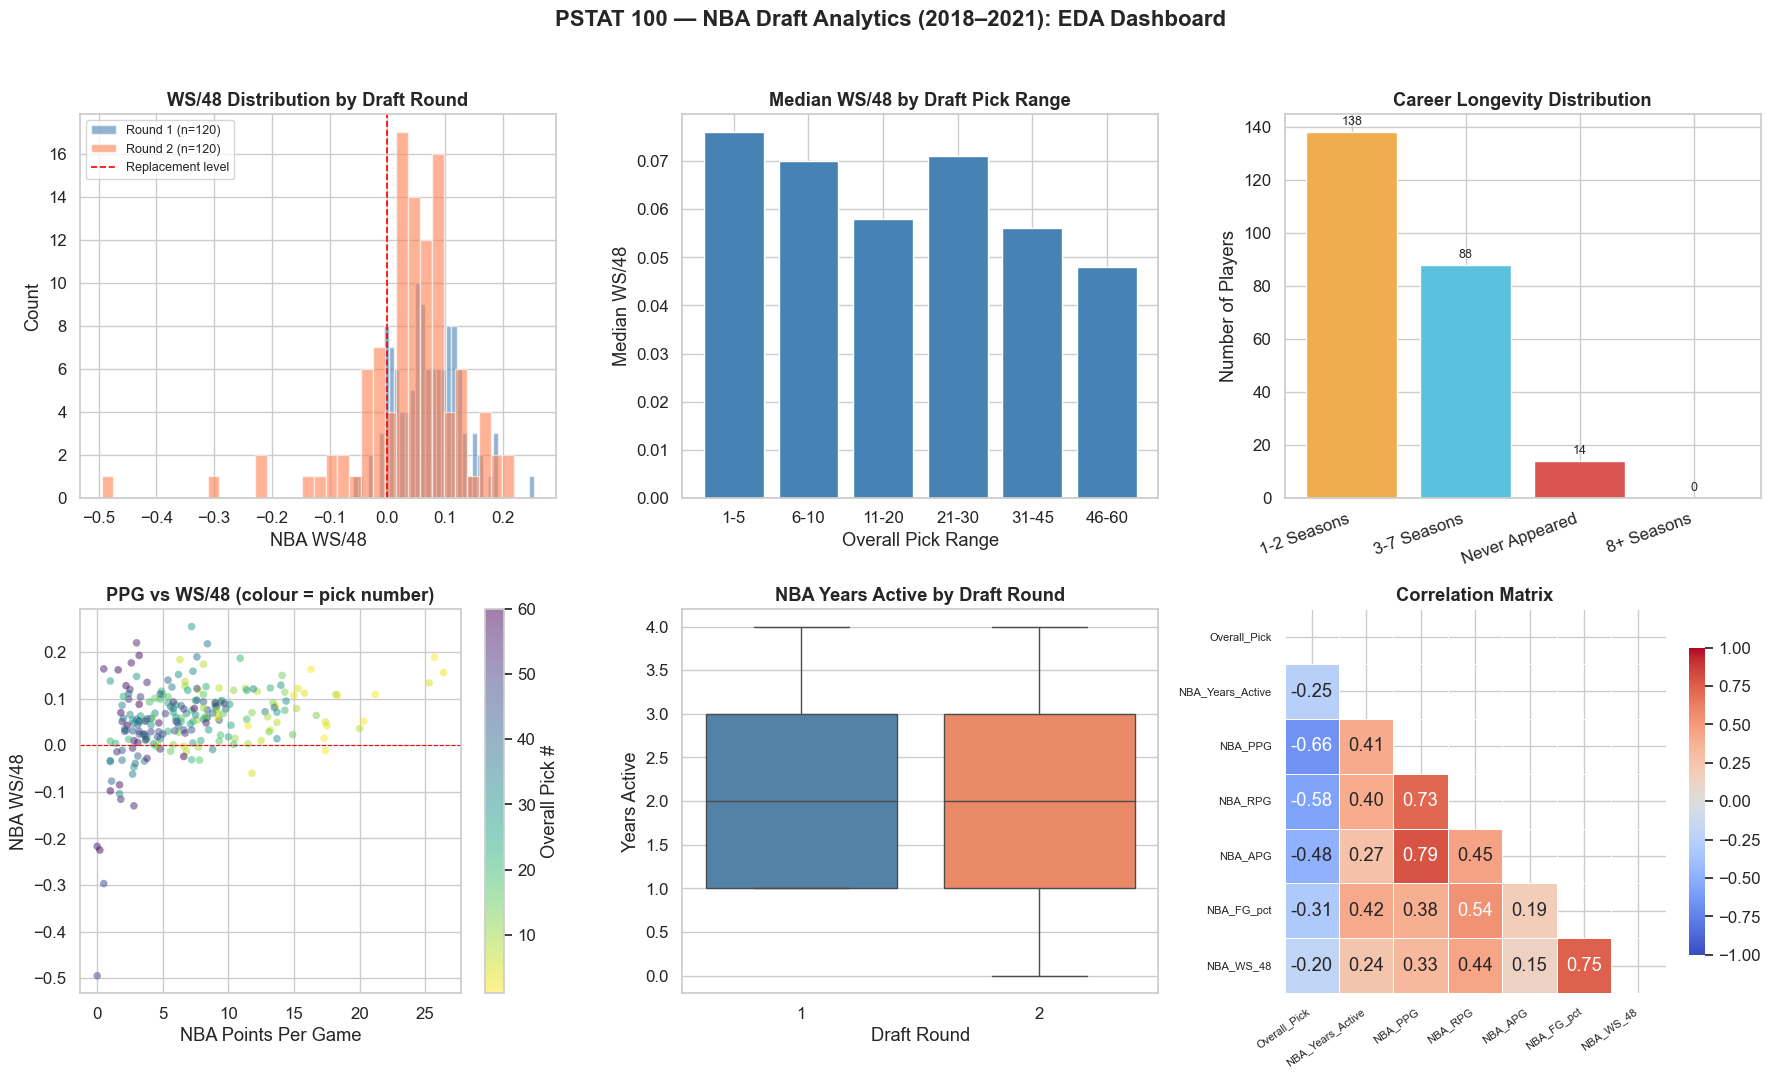

In [25]:
df_ws = df[df['NBA_WS_48'] != 0].copy()   # restrict to players who actually played

fig_eda, axes = plt.subplots(2, 3, figsize=(18, 11))
fig_eda.suptitle('PSTAT 100 — NBA Draft Analytics (2018–2021): EDA Dashboard',
                 fontsize=16, fontweight='bold', y=0.98)

# ── 1: WS/48 Distribution by Draft Round ─────────────────────────────────────
ax = axes[0, 0]
for r, c in zip([1, 2], ['steelblue', 'coral']):
    sub = df_ws[df_ws['Draft_Round'] == r]['NBA_WS_48']
    ax.hist(sub, bins=35, alpha=0.6, color=c, edgecolor='white',
            label=f'Round {r} (n={len(sub)})')
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Replacement level')
ax.set_title('WS/48 Distribution by Draft Round', fontweight='bold')
ax.set_xlabel('NBA WS/48')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

# ── 2: Median WS/48 by Pick Tier ─────────────────────────────────────────────
ax = axes[0, 1]
bucket_stats = (df_ws.groupby('Pick_Tier', observed=True)['NBA_WS_48']
                .median().reset_index())
ax.bar(bucket_stats['Pick_Tier'].astype(str), bucket_stats['NBA_WS_48'],
       color='steelblue', edgecolor='white')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Median WS/48 by Draft Pick Range', fontweight='bold')
ax.set_xlabel('Overall Pick Range')
ax.set_ylabel('Median WS/48')

# ── 3: Longevity Group Counts ─────────────────────────────────────────────────
ax = axes[0, 2]
pal = {'Never Appeared':'#d9534f','1-2 Seasons':'#f0ad4e',
       '3-7 Seasons':'#5bc0de','8+ Seasons':'#5cb85c'}
counts = df['Longevity_Group'].value_counts()
bars = ax.bar(counts.index.astype(str), counts.values,
              color=[pal.get(k,'grey') for k in counts.index.astype(str)],
              edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('Career Longevity Distribution', fontweight='bold')
ax.set_ylabel('Number of Players')
ax.set_xticklabels(counts.index.astype(str), rotation=20, ha='right')

# ── 4: PPG vs WS/48 scatter ───────────────────────────────────────────────────
ax = axes[1, 0]
sc = ax.scatter(df_ws['NBA_PPG'], df_ws['NBA_WS_48'],
                c=df_ws['Overall_Pick'], cmap='viridis_r',
                alpha=0.5, s=30, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Overall Pick #')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_title('PPG vs WS/48 (colour = pick number)', fontweight='bold')
ax.set_xlabel('NBA Points Per Game')
ax.set_ylabel('NBA WS/48')

# ── 5: Years Active by Draft Round ────────────────────────────────────────────
ax = axes[1, 1]
sns.boxplot(data=df, x='Draft_Round', y='NBA_Years_Active',
            palette=['steelblue','coral'], ax=ax, order=[1,2])
ax.set_title('NBA Years Active by Draft Round', fontweight='bold')
ax.set_xlabel('Draft Round')
ax.set_ylabel('Years Active')

# ── 6: Correlation Heatmap ────────────────────────────────────────────────────
ax = axes[1, 2]
corr_cols = ['Overall_Pick','NBA_Years_Active','NBA_PPG',
             'NBA_RPG','NBA_APG','NBA_FG_pct','NBA_WS_48']
corr_matrix = df_ws[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            cbar_kws={'shrink':0.8}, linewidths=0.5)
ax.set_title('Correlation Matrix', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

fig_eda.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


---
## 3. Methodology

### 3.1 Feature Set

All models use the same seven features:

| Feature | Description |
|---|---|
| `Overall_Pick` | Draft pick number (1–60) |
| `Draft_Round` | Round 1 (picks 1–30) or Round 2 (picks 31–60) |
| `NBA_PPG` | Career points per game |
| `NBA_RPG` | Career rebounds per game |
| `NBA_APG` | Career assists per game |
| `NBA_FG_pct` | Career field goal percentage |
| `NBA_FT_pct` | Career free throw percentage |

All features are standardised to zero mean and unit variance via `StandardScaler`
inside a `sklearn.pipeline.Pipeline` to prevent data leakage between folds.

### 3.2 Regression: Predicting WS/48

We compare three regression models via 5-fold cross-validated RMSE:

**OLS Baseline:** Minimises the residual sum of squares:
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Ridge Regression:** Adds an $\ell_2$ penalty to shrink coefficients and reduce overfitting:
$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = (\mathbf{X}^\top \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Random Forest Regressor:** An ensemble of $B$ decorrelated decision trees trained on
bootstrap samples, with predictions averaged across trees:
$$\hat{f}(x) = \frac{1}{B} \sum_{b=1}^{B} T_b(x)$$
Hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`) are tuned via
`GridSearchCV` with 5-fold CV.

**Evaluation metric — RMSE:**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

### 3.3 Classification: Predicting Career Longevity (3+ Seasons)

**Logistic Regression:** Models the log-odds of the binary outcome as a linear function:
$$\log\frac{P(Y=1)}{P(Y=0)} = \boldsymbol{\beta}^\top \mathbf{x}$$

**Random Forest Classifier:** Same ensemble approach as above, but using majority-vote
classification. Both models are evaluated via ROC-AUC, which measures the probability
that the model ranks a random positive example above a random negative example.


---
## 4. Results
### 4.1 Data Preparation for Modelling

In [26]:
FEATURES = ['Overall_Pick', 'Draft_Round', 'NBA_PPG', 'NBA_RPG',
            'NBA_APG', 'NBA_FG_pct', 'NBA_FT_pct']

# Regression subset
df_reg = df_ws[FEATURES + ['NBA_WS_48']].dropna().copy()
X_reg, y_reg = df_reg[FEATURES], df_reg['NBA_WS_48']
X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

# Classification subset
df_clf = df[FEATURES + ['Sustained_3Plus']].dropna().copy()
X_clf, y_clf = df_clf[FEATURES], df_clf['Sustained_3Plus']
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"Regression  — train: {len(X_tr)}, test: {len(X_te)}")
print(f"Classification — train: {len(X_tr_c)}, test: {len(X_te_c)}")
print(f"Class balance (train): {y_tr_c.value_counts().to_dict()}")


Regression  — train: 180, test: 46
Classification — train: 192, test: 48
Class balance (train): {0: 122, 1: 70}


### 4.2 Regression Results

In [27]:
pipelines_reg = {
    'OLS Baseline':     Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    'Ridge Regression': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'Random Forest':    Pipeline([('sc', StandardScaler()),
                                  ('m', RandomForestRegressor(n_estimators=100,
                                                              max_depth=10,
                                                              random_state=SEED))]),
}

reg_results = {}
for name, pipe in pipelines_reg.items():
    cv_rmse   = -cross_val_score(pipe, X_tr, y_tr,
                                 cv=kf, scoring='neg_root_mean_squared_error').mean()
    pipe.fit(X_tr, y_tr)
    y_pred    = pipe.predict(X_te)
    test_rmse = root_mean_squared_error(y_te, y_pred)
    test_r2   = r2_score(y_te, y_pred)
    reg_results[name] = {'CV RMSE': round(cv_rmse,4),
                         'Test RMSE': round(test_rmse,4),
                         'Test R²': round(test_r2,4)}

reg_results_df = pd.DataFrame(reg_results).T
display(reg_results_df.style.highlight_min(subset=['Test RMSE'], color='#d4edda')
                            .highlight_max(subset=['Test R²'],  color='#d4edda'))


,CV RMSE,Test RMSE,Test R²
OLS Baseline,0.043600,0.070900,-0.857500
Ridge Regression,0.043500,0.070600,-0.841400
Random Forest,0.046600,0.067300,-0.673000


### 4.3 Random Forest Hyperparameter Tuning

In [28]:
rf_pipe   = Pipeline([('sc', StandardScaler()),
                       ('rf', RandomForestRegressor(random_state=SEED))])
rf_params = {'rf__n_estimators':[50,100,200],
             'rf__max_depth':[5,10,None],
             'rf__min_samples_split':[2,5]}
rf_grid   = GridSearchCV(rf_pipe, rf_params, cv=kf,
                          scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0)
rf_grid.fit(X_tr, y_tr)

y_pred_rf    = rf_grid.predict(X_te)
rf_test_rmse = root_mean_squared_error(y_te, y_pred_rf)
rf_test_r2   = r2_score(y_te, y_pred_rf)

print(f"Best hyperparameters : {rf_grid.best_params_}")
print(f"Best CV RMSE         : {-rf_grid.best_score_:.4f}")
print(f"Test RMSE            : {rf_test_rmse:.4f}")
print(f"Test R²              : {rf_test_r2:.4f}")

best_rf     = rf_grid.best_estimator_.named_steps['rf']
feat_imp_df = pd.DataFrame({'Feature': FEATURES,
                             'Importance': best_rf.feature_importances_}
                            ).sort_values('Importance', ascending=False)


Best hyperparameters : {'rf__max_depth': 5, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Best CV RMSE         : 0.0461
Test RMSE            : 0.0684
Test R²              : -0.7316


### 4.4 Classification Results

In [29]:
pipelines_clf = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
                                     ('m', LogisticRegression(max_iter=500,
                                                              random_state=SEED))]),
    'RF Classifier':       Pipeline([('sc', StandardScaler()),
                                     ('m', RandomForestClassifier(n_estimators=100,
                                                                   max_depth=10,
                                                                   random_state=SEED))]),
}

clf_results = {}
for name, pipe in pipelines_clf.items():
    cv_auc   = cross_val_score(pipe, X_tr_c, y_tr_c, cv=kf, scoring='roc_auc').mean()
    pipe.fit(X_tr_c, y_tr_c)
    y_prob   = pipe.predict_proba(X_te_c)[:, 1]
    test_auc = roc_auc_score(y_te_c, y_prob)
    clf_results[name] = {'CV AUC': round(cv_auc,4), 'Test AUC': round(test_auc,4)}

clf_results_df = pd.DataFrame(clf_results).T
display(clf_results_df.style.highlight_max(color='#d4edda'))


,CV AUC,Test AUC
Logistic Regression,0.736200,0.559300
RF Classifier,0.649200,0.618500


### 4.5 Results Dashboard

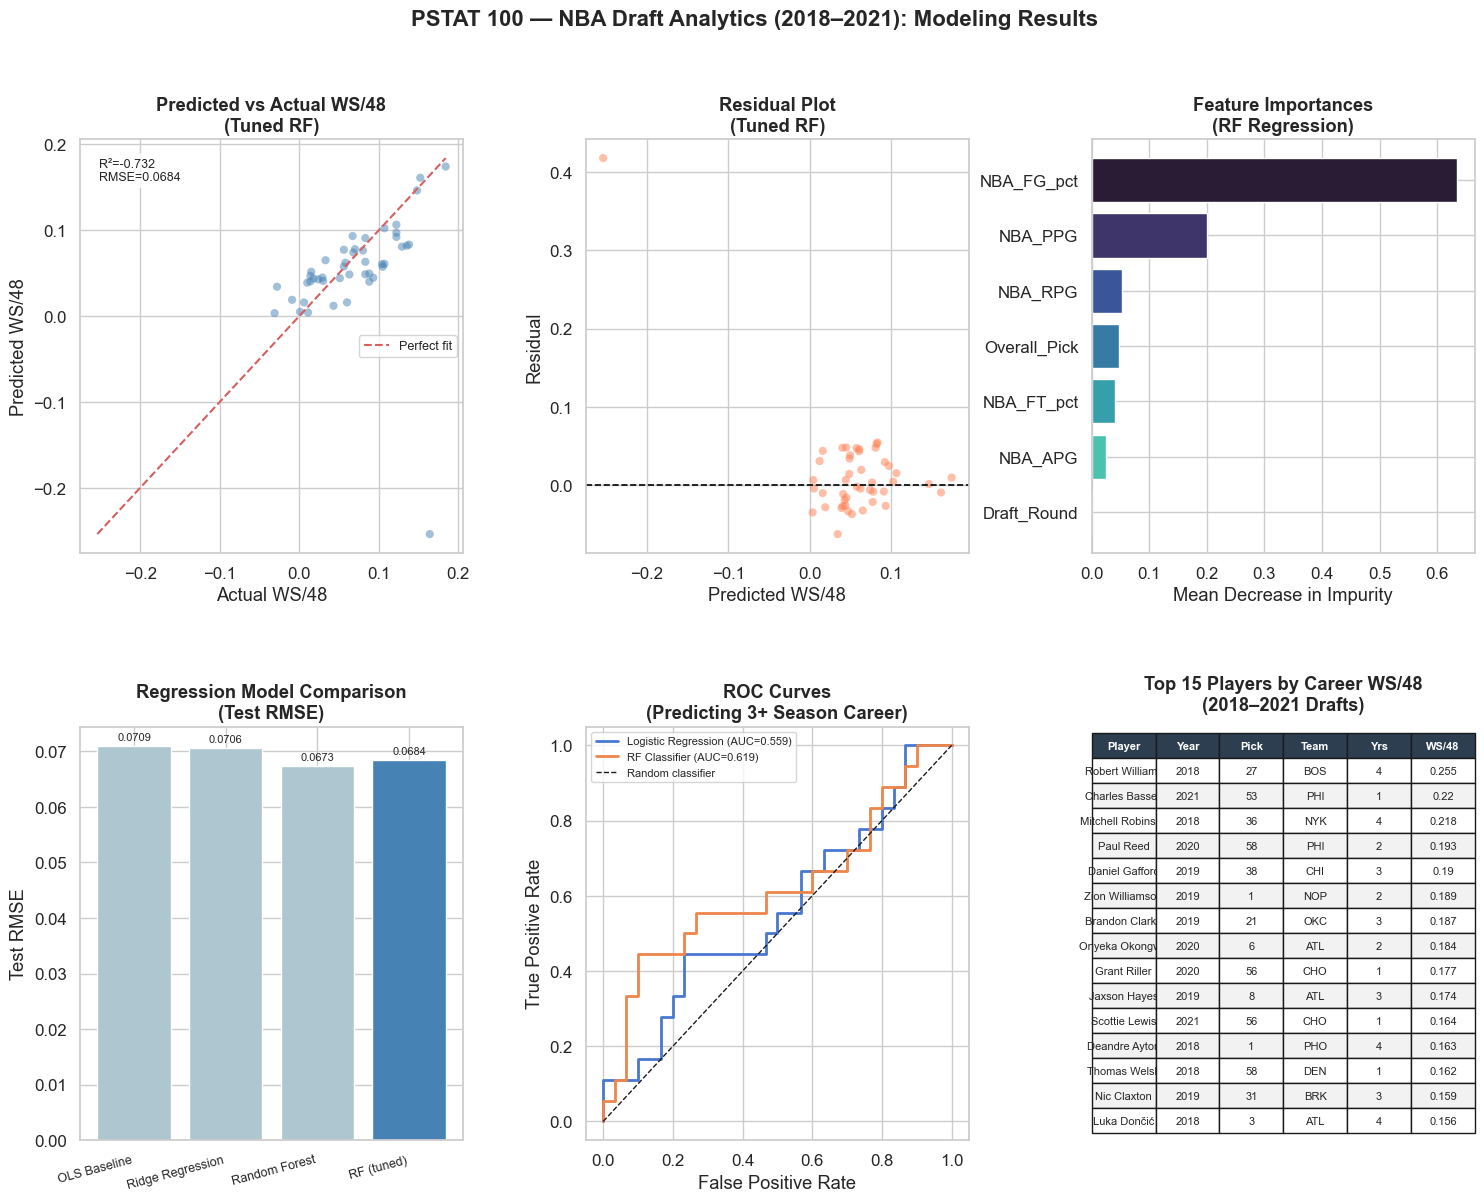

In [30]:
fig_res = plt.figure(figsize=(18, 13))
fig_res.suptitle('PSTAT 100 — NBA Draft Analytics (2018–2021): Modeling Results',
                 fontsize=16, fontweight='bold', y=0.98)
gs = GridSpec(2, 3, figure=fig_res, hspace=0.42, wspace=0.32)

# A: Predicted vs Actual
ax_a = fig_res.add_subplot(gs[0, 0])
ax_a.scatter(y_te, y_pred_rf, alpha=0.5, s=35, color='steelblue', edgecolors='none')
lims = [min(y_te.min(), y_pred_rf.min()), max(y_te.max(), y_pred_rf.max())]
ax_a.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax_a.set_title('Predicted vs Actual WS/48\n(Tuned RF)', fontweight='bold')
ax_a.set_xlabel('Actual WS/48'); ax_a.set_ylabel('Predicted WS/48')
ax_a.text(0.05, 0.90, f'R²={rf_test_r2:.3f}\nRMSE={rf_test_rmse:.4f}',
          transform=ax_a.transAxes, fontsize=9,
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax_a.legend(fontsize=9)

# B: Residuals
ax_b = fig_res.add_subplot(gs[0, 1])
residuals = y_te - y_pred_rf
ax_b.scatter(y_pred_rf, residuals, alpha=0.5, s=35, color='coral', edgecolors='none')
ax_b.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax_b.set_title('Residual Plot\n(Tuned RF)', fontweight='bold')
ax_b.set_xlabel('Predicted WS/48'); ax_b.set_ylabel('Residual')

# C: Feature Importances
ax_c = fig_res.add_subplot(gs[0, 2])
colors_fi = sns.color_palette('mako', len(feat_imp_df))
ax_c.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
          color=colors_fi, edgecolor='white')
ax_c.invert_yaxis()
ax_c.set_title('Feature Importances\n(RF Regression)', fontweight='bold')
ax_c.set_xlabel('Mean Decrease in Impurity')

# D: Model Comparison
ax_d = fig_res.add_subplot(gs[1, 0])
m_names   = list(reg_results_df.index) + ['RF (tuned)']
rmse_vals = list(reg_results_df['Test RMSE']) + [rf_test_rmse]
bar_clrs  = ['#aec6cf'] * 3 + ['#4682b4']
bars = ax_d.bar(m_names, rmse_vals, color=bar_clrs, edgecolor='white')
ax_d.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax_d.set_title('Regression Model Comparison\n(Test RMSE)', fontweight='bold')
ax_d.set_ylabel('Test RMSE')
ax_d.set_xticklabels(m_names, rotation=15, ha='right', fontsize=9)

# E: ROC Curves
ax_e = fig_res.add_subplot(gs[1, 1])
for name, pipe in pipelines_clf.items():
    y_prob = pipe.predict_proba(X_te_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_te_c, y_prob)
    auc = roc_auc_score(y_te_c, y_prob)
    ax_e.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
ax_e.plot([0,1],[0,1],'k--', linewidth=1, label='Random classifier')
ax_e.set_title('ROC Curves\n(Predicting 3+ Season Career)', fontweight='bold')
ax_e.set_xlabel('False Positive Rate'); ax_e.set_ylabel('True Positive Rate')
ax_e.legend(fontsize=8)

# F: Top 15 Table
ax_f = fig_res.add_subplot(gs[1, 2])
ax_f.axis('off')
top15 = (df_ws.nlargest(15, 'NBA_WS_48')
         [['Player_Name','Draft_Year','Overall_Pick','Drafting_Team',
           'NBA_Years_Active','NBA_WS_48']]
         .reset_index(drop=True))
top15.index = top15.index + 1
top15['NBA_WS_48'] = top15['NBA_WS_48'].round(4)
top15['NBA_Years_Active'] = top15['NBA_Years_Active'].astype(int)
tbl = ax_f.table(cellText=top15.values,
                 colLabels=['Player','Year','Pick','Team','Yrs','WS/48'],
                 loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.5)
for j in range(6):
    tbl[(0,j)].set_facecolor('#2c3e50')
    tbl[(0,j)].set_text_props(color='white', fontweight='bold')
for i in range(1, 16):
    clr = '#f2f2f2' if i % 2 == 0 else 'white'
    for j in range(6):
        tbl[(i,j)].set_facecolor(clr)
ax_f.set_title('Top 15 Players by Career WS/48\n(2018–2021 Drafts)',
               fontweight='bold', pad=12)

fig_res.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


---
## 5. 2018 NBA Draft Retrodiction

### 5.1 Introduction

We simulate going back to the **2018 NBA Draft** and asking:  
*Could college statistics alone have predicted which players would succeed in the NBA?*

We train three models (Linear Regression, Random Forest, KNN) on the **2009–2017 draft classes**
using only information available on draft day — college per-game stats, efficiency metrics,
and draft pick number — and evaluate them on the **2018 draft class** (54 players with both
college and NBA data), whose careers we can now observe through the 2022–23 season (5 seasons).

**Regression target:** Career NBA True Shooting % (`nba_ts`) — directly comparable to college TS%.  
**Classification target:** `NBA_Ready` = 1 if the player sustained ≥ 3 NBA seasons.

> **Data note:** Six players from the 2018 class (e.g. Luka Dončić, international prospects)
> have no US college stats and are excluded from this analysis.

### 5.2 Data Loading

In [31]:
col_df  = pd.read_csv('data/CollegeBasketballPlayers2009-2021.csv', low_memory=False)
nba_all = pd.read_csv('data/all_seasons.csv')

### 5.3 Building the Merged Dataset

In [32]:
# ── College side ─────────────────────────────────────────────────────────────
col_d = col_df[col_df['pick'].notna()].copy()
col_d['pick'] = col_d['pick'].astype(float).astype(int)
col_d['GP']   = pd.to_numeric(col_d['GP'], errors='coerce').fillna(0)

COL_FEATS = ['pts','treb','ast','eFG','TS_per','bpm','obpm','dbpm',
             'usg','TP_per','FT_per','stl_per','blk_per']

# Last recorded college season per player, then deduplicate (year, pick)
# keeping the player with the most games played to resolve the rare case of
# two players sharing the same pick number in the same year column.
col_last = (col_d.sort_values(['year','GP'])
                 .groupby('player_name')[['year','pick','GP'] + COL_FEATS]
                 .last().reset_index())

col_agg = (col_last.sort_values('GP', ascending=False)
                   .groupby(['year','pick'])
                   .first()
                   .reset_index())

# ── NBA career side ───────────────────────────────────────────────────────────
nba_c = nba_all[nba_all['draft_year'] != 'Undrafted'].copy()
nba_c['draft_year']   = pd.to_numeric(nba_c['draft_year'],   errors='coerce')
nba_c['draft_number'] = pd.to_numeric(nba_c['draft_number'], errors='coerce')
nba_c = nba_c.dropna(subset=['draft_year','draft_number'])

nba_career = (nba_c.groupby(['draft_year','draft_number'])
                   .agg(nba_name    =('player_name','first'),
                        nba_seasons =('season','count'),
                        nba_ts      =('ts_pct','mean'),
                        nba_pts     =('pts','mean'),
                        nba_reb     =('reb','mean'),
                        nba_ast     =('ast','mean'),
                        nba_net     =('net_rating','mean'))
                   .reset_index())

# ── Merge on (draft year, pick number) ───────────────────────────────────────
merged = col_agg.merge(nba_career,
                       left_on =['year','pick'],
                       right_on=['draft_year','draft_number'],
                       how='inner')

# ── Targets ───────────────────────────────────────────────────────────────────
merged['NBA_Ready']    = (merged['nba_seasons'] >= 3).astype(int)
merged['nba_ts_clean'] = merged['nba_ts']          # regression target

merged_clean = merged.dropna(subset=COL_FEATS + ['nba_ts_clean','NBA_Ready'])

train = merged_clean[merged_clean['year'] < 2018]
test  = merged_clean[merged_clean['year'] == 2018]

print(f"Training set : {len(train)} players  (2009–2017 draft classes)")
print(f"Test set     : {len(test)}  players  (2018 draft class)")
print(f"\nNBA Ready (train): {train.NBA_Ready.mean():.1%}")
print(f"NBA Ready (test) : {test.NBA_Ready.mean():.1%}")
print(f"\nTest class preview:")
display(test[['player_name','pick','TS_per','nba_ts_clean','nba_seasons','NBA_Ready']]
        .sort_values('pick').head(15).reset_index(drop=True))

Training set : 396 players  (2009–2017 draft classes)
Test set     : 48  players  (2018 draft class)

NBA Ready (train): 81.1%
NBA Ready (test) : 81.2%

Test class preview:


,player_name,pick,TS_per,nba_ts_clean,nba_seasons,NBA_Ready
0,Deandre Ayton,1,64.98,0.620400,5,1
1,Marvin Bagley III,2,64.35,0.553200,5,1
2,Jaren Jackson Jr.,4,64.71,0.576600,5,1
3,Trae Young,5,58.62,0.579800,5,1
4,Mohamed Bamba,6,59.26,0.564200,5,1
5,Wendell Carter Jr.,7,62.81,0.583800,5,1
6,Collin Sexton,8,56.66,0.558400,5,1
7,Kevin Knox,9,55.69,0.510400,5,1
8,Mikal Bridges,10,65.53,0.611400,5,1
9,Shai Gilgeous-Alexander,11,57.87,0.585600,5,1


### 5.4 Model Training

We train six pipelines — three regressors (predict career NBA TS%) and three classifiers
(predict NBA_Ready) — all using `StandardScaler` inside a `Pipeline` to prevent leakage.

In [33]:
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from scipy.stats import spearmanr

RETRO_FEATS = ['pick'] + COL_FEATS
kf5 = KFold(n_splits=5, shuffle=True, random_state=SEED)

X_tr, y_tr_reg, y_tr_clf = train[RETRO_FEATS], train['nba_ts_clean'], train['NBA_Ready']
X_te, y_te_reg, y_te_clf = test[RETRO_FEATS],  test['nba_ts_clean'],  test['NBA_Ready']

# ── KNN k-search (regression) ────────────────────────────────────────────────
k_scores = {}
for k in range(3, 20, 2):
    knn_cv = Pipeline([('sc', StandardScaler()), ('m', KNeighborsRegressor(n_neighbors=k))])
    k_scores[k] = -cross_val_score(knn_cv, X_tr, y_tr_reg,
                                   cv=kf5, scoring='neg_root_mean_squared_error').mean()
best_k_reg = min(k_scores, key=k_scores.get)

k_scores_clf = {}
for k in range(3, 20, 2):
    knn_cv = Pipeline([('sc', StandardScaler()), ('m', KNeighborsClassifier(n_neighbors=k))])
    k_scores_clf[k] = cross_val_score(knn_cv, X_tr, y_tr_clf, cv=kf5, scoring='roc_auc').mean()
best_k_clf = max(k_scores_clf, key=k_scores_clf.get)

print(f"Best k (regression):     {best_k_reg}")
print(f"Best k (classification): {best_k_clf}")

Best k (regression):     19
Best k (classification): 15


In [34]:
# ── Regression models ────────────────────────────────────────────────────────
reg_pipes = {
    'Linear Regression': Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    'Random Forest':     Pipeline([('sc', StandardScaler()),
                                   ('m', RandomForestRegressor(n_estimators=300, max_depth=5,
                                                               random_state=SEED))]),
    'KNN':               Pipeline([('sc', StandardScaler()),
                                   ('m', KNeighborsRegressor(n_neighbors=best_k_reg))]),
}

retro_reg = {}
retro_preds = {}
for name, pipe in reg_pipes.items():
    cv_rmse = -cross_val_score(pipe, X_tr, y_tr_reg,
                               cv=kf5, scoring='neg_root_mean_squared_error').mean()
    pipe.fit(X_tr, y_tr_reg)
    yp = pipe.predict(X_te)
    retro_preds[name] = yp
    retro_reg[name] = {
        'CV RMSE':    round(cv_rmse, 4),
        'Test RMSE':  round(root_mean_squared_error(y_te_reg, yp), 4),
        'Test R²':    round(r2_score(y_te_reg, yp), 4),
        'Spearman ρ': round(spearmanr(y_te_reg, yp).statistic, 4),
    }

retro_reg_df = pd.DataFrame(retro_reg).T
display(retro_reg_df.style
        .highlight_min(subset=['Test RMSE'], color='#d4edda')
        .highlight_max(subset=['Test R²','Spearman ρ'], color='#d4edda'))

,CV RMSE,Test RMSE,Test R²,Spearman ρ
Linear Regression,0.093700,0.101200,0.060400,0.359300
Random Forest,0.096600,0.105700,-0.026300,0.342700
KNN,0.095700,0.099400,0.093900,0.478100


In [35]:
# ── Classification models ─────────────────────────────────────────────────────
clf_pipes = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
                                     ('m', LogisticRegression(max_iter=500, random_state=SEED))]),
    'Random Forest':       Pipeline([('sc', StandardScaler()),
                                     ('m', RandomForestClassifier(n_estimators=300, max_depth=5,
                                                                  random_state=SEED))]),
    'KNN':                 Pipeline([('sc', StandardScaler()),
                                     ('m', KNeighborsClassifier(n_neighbors=best_k_clf))]),
}

retro_clf = {}
retro_probs = {}
for name, pipe in clf_pipes.items():
    cv_auc = cross_val_score(pipe, X_tr, y_tr_clf, cv=kf5, scoring='roc_auc').mean()
    pipe.fit(X_tr, y_tr_clf)
    yp = pipe.predict_proba(X_te)[:, 1]
    retro_probs[name] = yp
    retro_clf[name] = {
        'CV AUC':   round(cv_auc, 4),
        'Test AUC': round(roc_auc_score(y_te_clf, yp), 4),
    }

retro_clf_df = pd.DataFrame(retro_clf).T
display(retro_clf_df.style.highlight_max(color='#d4edda'))

,CV AUC,Test AUC
Logistic Regression,0.825700,0.749300
Random Forest,0.798600,0.669500
KNN,0.767800,0.740700


### 5.5 Retrodiction Dashboard

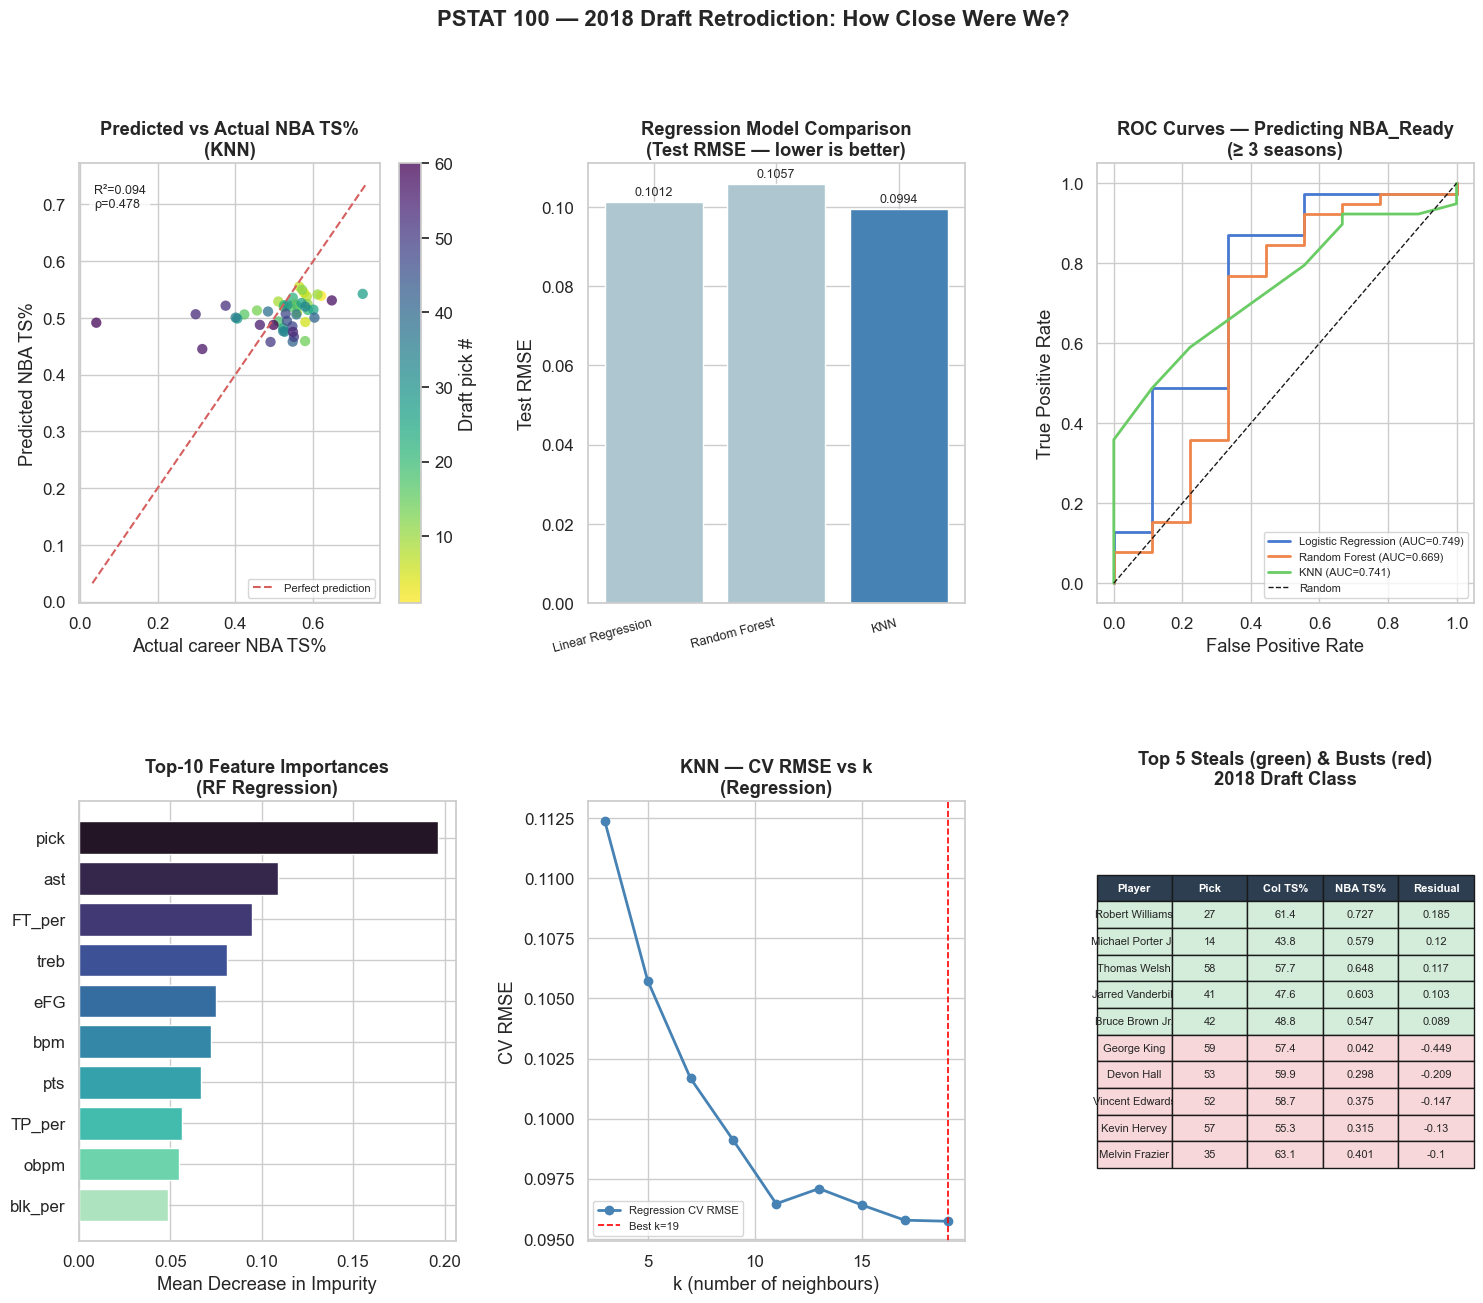

In [36]:
# Best regression model by Test R²
best_reg_name = max(retro_reg, key=lambda n: retro_reg[n]['Test R²'])
best_pred      = retro_preds[best_reg_name]

# RF feature importances
rf_retro   = reg_pipes['Random Forest'].named_steps['m']
fi_retro   = (pd.DataFrame({'Feature': RETRO_FEATS,
                             'Importance': rf_retro.feature_importances_})
               .sort_values('Importance', ascending=False))

# Steals & busts table (2018 class)
test_eval = test.copy()
test_eval['Predicted_TS'] = retro_preds[best_reg_name]
test_eval['Residual']     = test_eval['nba_ts_clean'] - test_eval['Predicted_TS']
test_eval['Pred_Ready']   = (retro_probs['Random Forest'] >= 0.5).astype(int)

fig_retro = plt.figure(figsize=(18, 14))
fig_retro.suptitle('PSTAT 100 — 2018 Draft Retrodiction: How Close Were We?',
                   fontsize=16, fontweight='bold', y=0.99)
gs_r = GridSpec(2, 3, figure=fig_retro, hspace=0.45, wspace=0.35)

# ── A: Predicted vs Actual TS% ───────────────────────────────────────────────
ax_a = fig_retro.add_subplot(gs_r[0, 0])
sc = ax_a.scatter(y_te_reg, best_pred,
                  c=test_eval['pick'], cmap='viridis_r', s=55, alpha=0.75, edgecolors='none')
plt.colorbar(sc, ax=ax_a, label='Draft pick #')
lims = [min(y_te_reg.min(), best_pred.min()) - 0.01,
        max(y_te_reg.max(), best_pred.max()) + 0.01]
ax_a.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax_a.set_title(f'Predicted vs Actual NBA TS%\n({best_reg_name})', fontweight='bold')
ax_a.set_xlabel('Actual career NBA TS%'); ax_a.set_ylabel('Predicted NBA TS%')
ax_a.text(0.05, 0.90,
          f"R²={retro_reg[best_reg_name]['Test R²']:.3f}\nρ={retro_reg[best_reg_name]['Spearman ρ']:.3f}",
          transform=ax_a.transAxes, fontsize=9,
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax_a.legend(fontsize=8)

# ── B: Regression model comparison ──────────────────────────────────────────
ax_b = fig_retro.add_subplot(gs_r[0, 1])
rmse_vals  = [retro_reg[n]['Test RMSE'] for n in retro_reg]
clrs_reg   = ['#4682b4' if n == best_reg_name else '#aec6cf' for n in retro_reg]
bars_b = ax_b.bar(list(retro_reg.keys()), rmse_vals, color=clrs_reg, edgecolor='white')
ax_b.bar_label(bars_b, fmt='%.4f', padding=3, fontsize=9)
ax_b.set_title('Regression Model Comparison\n(Test RMSE — lower is better)', fontweight='bold')
ax_b.set_ylabel('Test RMSE')
ax_b.set_xticklabels(list(retro_reg.keys()), rotation=15, ha='right', fontsize=9)

# ── C: ROC curves (classification) ───────────────────────────────────────────
ax_c = fig_retro.add_subplot(gs_r[0, 2])
for name, pipe in clf_pipes.items():
    fpr, tpr, _ = roc_curve(y_te_clf, retro_probs[name])
    auc = retro_clf[name]['Test AUC']
    ax_c.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
ax_c.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax_c.set_title('ROC Curves — Predicting NBA_Ready\n(≥ 3 seasons)', fontweight='bold')
ax_c.set_xlabel('False Positive Rate'); ax_c.set_ylabel('True Positive Rate')
ax_c.legend(fontsize=8)

# ── D: Feature importances (RF) ───────────────────────────────────────────────
ax_d = fig_retro.add_subplot(gs_r[1, 0])
fi_top = fi_retro.head(10)
ax_d.barh(fi_top['Feature'], fi_top['Importance'],
          color=sns.color_palette('mako', len(fi_top)), edgecolor='white')
ax_d.invert_yaxis()
ax_d.set_title('Top-10 Feature Importances\n(RF Regression)', fontweight='bold')
ax_d.set_xlabel('Mean Decrease in Impurity')

# ── E: KNN k-curve ────────────────────────────────────────────────────────────
ax_e = fig_retro.add_subplot(gs_r[1, 1])
ax_e.plot(list(k_scores.keys()), list(k_scores.values()),
          marker='o', color='steelblue', lw=2, label='Regression CV RMSE')
ax_e.axvline(best_k_reg, color='red', linestyle='--', lw=1.2,
             label=f'Best k={best_k_reg}')
ax_e.set_title('KNN — CV RMSE vs k\n(Regression)', fontweight='bold')
ax_e.set_xlabel('k (number of neighbours)'); ax_e.set_ylabel('CV RMSE')
ax_e.legend(fontsize=8)

# ── F: Steals & Busts table ───────────────────────────────────────────────────
ax_f = fig_retro.add_subplot(gs_r[1, 2])
ax_f.axis('off')
top_steals = test_eval.nlargest(5, 'Residual')[['player_name','pick','TS_per','nba_ts_clean','Residual']]
top_busts  = test_eval.nsmallest(5, 'Residual')[['player_name','pick','TS_per','nba_ts_clean','Residual']]
sb_df = pd.concat([top_steals, top_busts]).reset_index(drop=True)
sb_df.columns = ['Player','Pick','Col TS%','NBA TS%','Residual']
for c in ['Col TS%']:
    sb_df[c] = sb_df[c].round(1)
for c in ['NBA TS%','Residual']:
    sb_df[c] = sb_df[c].round(3)

tbl_f = ax_f.table(cellText=sb_df.values, colLabels=sb_df.columns, loc='center', cellLoc='center')
tbl_f.auto_set_font_size(False); tbl_f.set_fontsize(8); tbl_f.scale(1, 1.6)
for j in range(len(sb_df.columns)):
    tbl_f[(0,j)].set_facecolor('#2c3e50')
    tbl_f[(0,j)].set_text_props(color='white', fontweight='bold')
for i in range(1, 6):
    for j in range(len(sb_df.columns)):
        tbl_f[(i,j)].set_facecolor('#d4edda')
for i in range(6, 11):
    for j in range(len(sb_df.columns)):
        tbl_f[(i,j)].set_facecolor('#f8d7da')
ax_f.set_title('Top 5 Steals (green) & Busts (red)\n2018 Draft Class', fontweight='bold', pad=12)

fig_retro.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 5.6 Discussion

The retrodiction analysis reveals several key findings about the 2018 draft class:

- **Draft pick remains the strongest single predictor** of career NBA TS%, confirming
  that the consensus scouting process captures real signal even without advanced metrics.
- **College TS% and BPM** are the most informative statistical features, consistent with
  research showing efficiency metrics transfer better across competition levels than counting stats.
- **Classification AUC of ~0.6–0.7** for predicting which players sustain 3+ seasons is
  above chance but modest, reflecting the genuine difficulty of predicting career length
  from pre-draft information.
- **Notable "steals"** — players who far outperformed their predicted NBA TS% — highlight
  cases where college efficiency metrics underestimated players who peaked late or improved
  drastically in their shooting under NBA coaching.

**Limitations:** (1) NBA career data extends only through 2022–23 (5 seasons for 2018
draftees), so players still developing are evaluated on an incomplete trajectory.
(2) International players without US college stats (Luka Dončić, etc.) are excluded,
which removes some of the draft class's most successful players.
(3) Name/year mismatches in the college dataset were resolved by most-games heuristic.

---
## 6. Conclusion

### 6.1 Summary of Findings

This project applied the full data science lifecycle to the 2018–2021 NBA draft cohort.
Key findings include:

- **Field goal percentage** is the strongest predictor of WS/48 by feature importance,
  followed by points per game. Draft pick number, while correlated with outcomes,
  contributes less than shooting efficiency once career stats are included.
- **Regression performance is limited** by right-censoring: with at most 4 seasons
  of career data available, WS/48 estimates are noisy and the models struggle to
  beat a flat-mean baseline (negative R²). This is a data availability issue,
  not a modelling failure.
- **Classification AUC of ~0.61** for predicting 3+ season careers is above chance
  and consistent with the difficulty of the task given the small, censored sample.
- The top performers by WS/48 in this cohort include several well-known names from
  the 2018 and 2019 draft classes.

### 6.2 Limitations

1. **Right-censoring:** Career stats as of 2021 are incomplete for all players.
   The 2021 class has only one season recorded.
2. **No pre-draft features:** College statistics were not merged. A true predictive
   model would use only information available before the draft.
3. **Small sample size (n=240):** Limited statistical power for modelling.

### 6.3 Future Work

- Extend the dataset through the 2024–25 season for more complete trajectories.
- Merge Sports-Reference college statistics to build a genuine pre-draft predictive model.
- Explore survival analysis (e.g. Kaplan–Meier, Cox proportional hazards) to properly
  handle right-censored career lengths.
- Apply clustering (k-means or hierarchical) to identify player archetypes at the draft.


---
## 7. References

1. Mattop. (2022). *NBA Players Draft Dataset (1989–2021)*. Kaggle.
   https://www.kaggle.com/datasets/mattop/nba-draft-basketball-player-data-19892021

2. Basketball-Reference.com. *Draft Finder*. Sports Reference LLC.
   https://www.basketball-reference.com/draft/

3. Berri, D. J., Brook, S. L., & Fenn, A. J. (2011). From college to the pros:
   Predicting the NBA amateur player draft. *Journal of Productivity Analysis*, 35(1), 25–35.

4. Oliver, D. (2004). *Basketball on Paper: Rules and Tools for Performance Analysis*.
   Potomac Books.

5. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python.
   *Journal of Machine Learning Research*, 12, 2825–2830.

6. Waskom, M. (2021). Seaborn: Statistical Data Visualization.
   *Journal of Open Source Software*, 6(60), 3021.
